# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan dalam eksperimen ini adalah Student Performance in Exams yang populer di Kaggle (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams). Dataset ini merekam data demografi dan latar belakang siswa (seperti jenis kelamin, tingkat pendidikan orang tua, tipe makan siang, dan keikutsertaan dalam kursus persiapan ujian) beserta nilai ujian mereka (Matematika, Membaca, dan Menulis).
   <br>
   <br>
2. **Tujuan Eksperimen**:  
   Kita akan melatih model Machine Learning untuk melakukan Klasifikasi. Tujuannya adalah memprediksi apakah seorang siswa diproyeksikan Lulus (1) atau Tidak Lulus (0) pada ujian Matematika (dengan asumsi nilai minimal kelulusan adalah 60). Prediksi ini didasarkan murni pada data latar belakang kehidupan siswa, tanpa melihat nilai ujian lainnya untuk mencegah kebocoran data (data leakage).


# **2. Import Library**


Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**


Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan


In [37]:
df = pd.read_csv('../StudentsPerformance_raw/StudentsPerformance.csv')

print("Dataset berhasil dimuat. Berikut beberapa baris pertama dari dataset:")
df.head()

Dataset berhasil dimuat. Berikut beberapa baris pertama dari dataset:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   average score                1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB

Statistik deskriptif:

Missing values per kolom:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                     

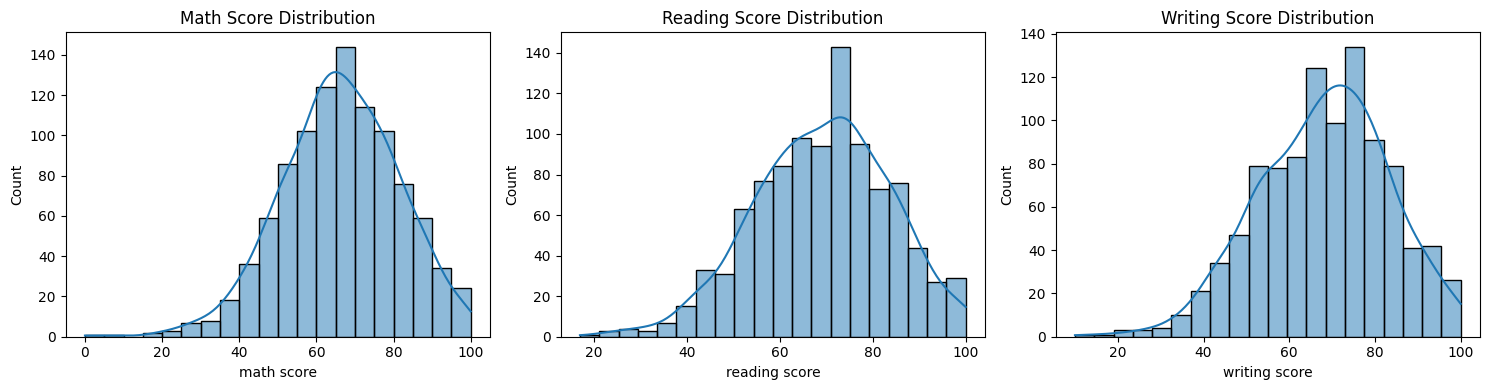

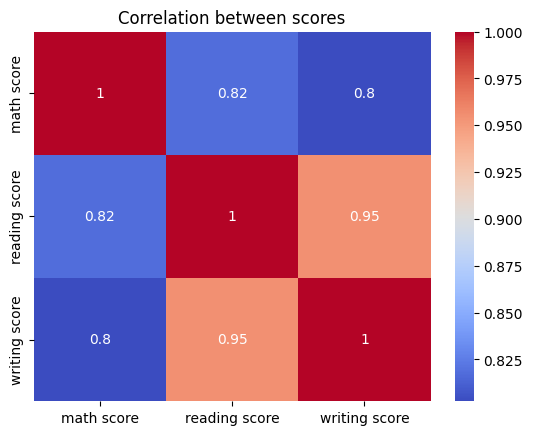

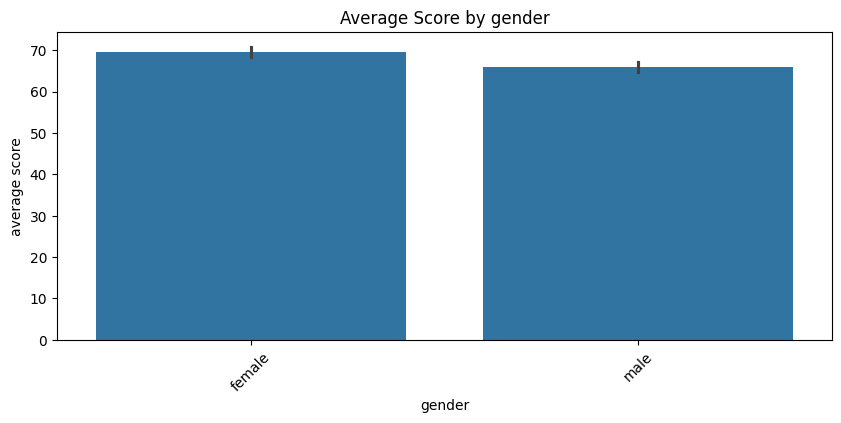

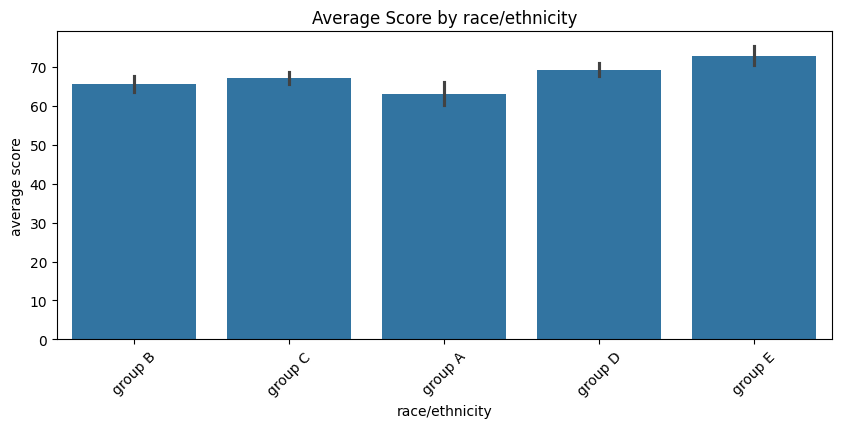

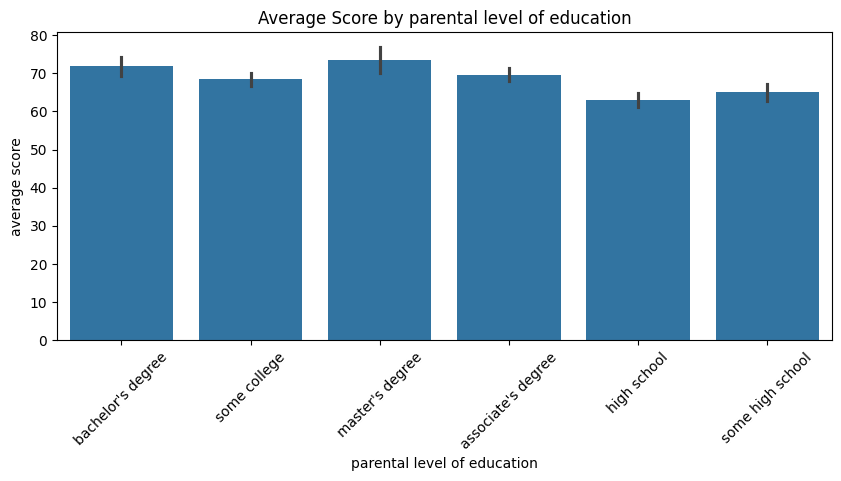

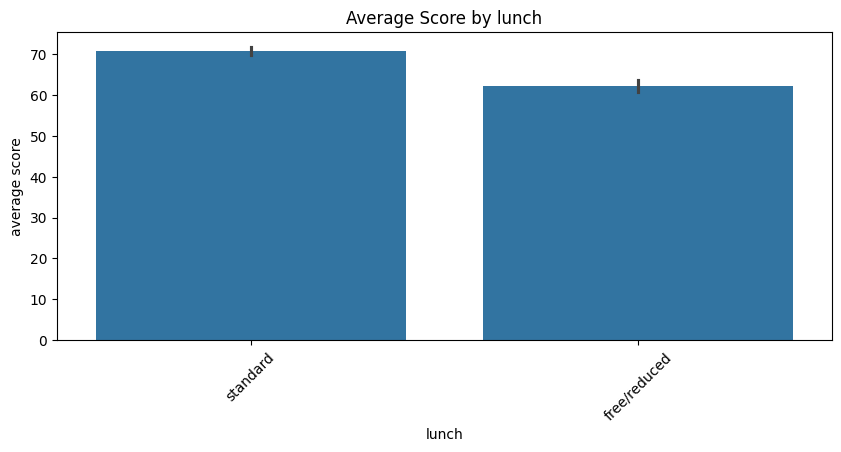

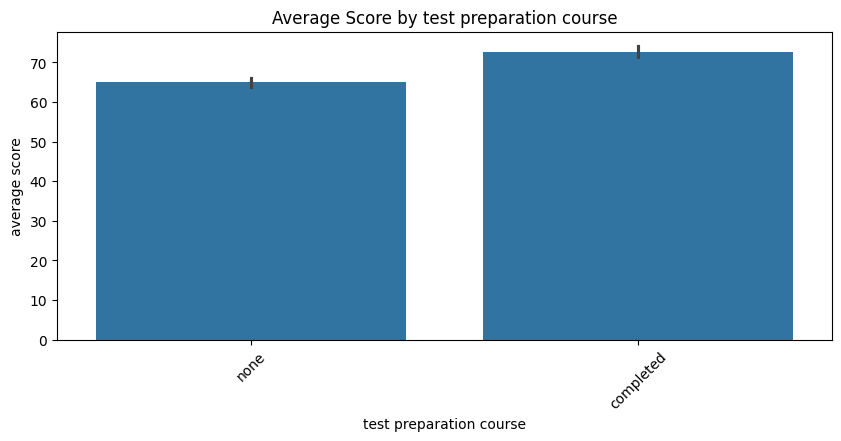

In [40]:
# Informasi dataset
print("Informasi dataset:")
df.info()

print("\nStatistik deskriptif:")
df.describe()

# Cek missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Cek duplikat
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

# Visualisasi distribusi nilai
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['math score'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Math Score Distribution')
sns.histplot(df['reading score'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Reading Score Distribution')
sns.histplot(df['writing score'], bins=20, kde=True, ax=axes[2])
axes[2].set_title('Writing Score Distribution')
plt.tight_layout()
plt.show()

# Korelasi antar fitur numerik (tidak ada korelasi dengan target karena target belum dibuat)
# Namun kita lihat korelasi antar nilai mata pelajaran
numeric_cols = ['math score', 'reading score', 'writing score']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between scores')
plt.show()

# Analisis pengaruh faktor kategorikal terhadap nilai rata-rata
df['average score'] = df[['math score','reading score','writing score']].mean(axis=1)

categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.barplot(data=df, x=col, y='average score')
    plt.title(f'Average Score by {col}')
    plt.xticks(rotation=45)
    plt.show()

# **5. Data Preprocessing**


Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:

1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.


In [42]:
import os

# 4.1. Menghapus kolom yang tidak diperlukan (jika ada)
# Tidak ada kolom ID, kita biarkan semua. Namun kita akan hapus kolom 'average score' karena ini hasil turunan
df_clean = df.drop('average score', axis=1)

# 4.2. Encoding data kategorikal (ubah teks menjadi angka)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# 4.3. Pisahkan fitur dan target
# Memprediksi 'math score' sebagai target (regresi)
X = df_clean.drop('math score', axis=1)
y = df_clean['math score']

# 4.4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.5. Normalisasi fitur numerik (kecuali fitur kategorikal yang sudah diencode)
# Fitur numerik hanya 'reading score' dan 'writing score' karena math score adalah target
feature_names = X.columns
numeric_features = ['reading score', 'writing score']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Cek hasil akhir
print("Bentuk X_train:", X_train.shape)
print("Bentuk X_test:", X_test.shape)
print("Contoh data setelah preprocessing:\n", X_train.head())

# Simpan data yang sudah diproses ke file menggunakan joblib
output_dir = 'StudentsPerformance_processing'
os.makedirs(output_dir, exist_ok=True)

joblib.dump((X_train, X_test, y_train, y_test), os.path.join(output_dir, 'processed_data.pkl'))
joblib.dump(scaler, os.path.join(output_dir, 'scaler.pkl'))
joblib.dump(label_encoders, os.path.join(output_dir, 'label_encoders.pkl'))
print("Data preprocessing selesai dan disimpan.")

Bentuk X_train: (800, 7)
Bentuk X_test: (200, 7)
Contoh data setelah preprocessing:
      gender  race/ethnicity  parental level of education  lunch  \
29        0               3                            3      1   
535       0               2                            1      0   
695       0               3                            4      0   
557       1               2                            3      0   
836       1               4                            2      1   

     test preparation course  reading score  writing score  
29                         1       0.030791       0.434053  
535                        0       0.930290       0.964701  
695                        1       1.345443       1.163694  
557                        1      -0.176786      -0.162925  
836                        1      -0.384363      -0.759904  
Data preprocessing selesai dan disimpan.
